In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
resc_raw=pd.read_csv('구급 현황_2023_전국.csv')

C:\Users\KDT30\AppData\Local\Temp\ipykernel_22408\2220765455.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  resc_raw=pd.read_csv('구급 현황_2023_전국.csv')


In [3]:
resc_raw.head()

,RLF_RPTP_NO,REG_CMPTN_SE_NM,PTN_OCRN_TYPE_NM,PTN_SYM_SE_NM,SRIL_ONCR_NM,HRTARST_NM,CRDVSC_CRVSSCR_SE_NM,TRFC_ACDNT_SE_NM,ETC_TRFC_ACDNT_NM,ANML_ETC_CLSF_NM,...,TRMN_SE_NM,GNDR_NM,PTN_CTPV_NM,CTPV_NM,SGG_NM,CTY_FRMVL_SE_NM,PTN_CR_NM,GRNDS2_DSTNC,GRNDS3_DSTNC,TRANS_CLSF_NM
0,1120104M00005,진행중,질병외,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1120104M00006,진행중,질병외,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1120104M00003,진행중,질병외,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1120104M00007,진행중,질병외,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1120104M00002,진행중,질병외,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
cols_info = pd.read_excel('소방청_전국 구급 현황_컬럼 정보 데이터.xlsx', header=1)
cols_info = cols_info[['컬럼 영문명', '컬럼 한글명']].set_index('컬럼 영문명')
cols_info.index = cols_info.index.str.upper()
cols_info =cols_info['컬럼 한글명']
cols_info

c:\Users\KDT30\anaconda3\envs\hani\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


컬럼 영문명
GRNDS2_DSTNC          2현장거리
GRNDS3_DSTNC          3현장거리
SEASN_NM                계절명
TRFC_ACDNT_SE_NM    교통사고구분명
RLF_RPTP_NO         구급보고서번호
                     ...   
PTN_CNTC_MM           환자접촉월
PTN_CNTC_DAY          환자접촉일
PTN_CNTC_YMD         환자접촉일자
PTN_SYM_SE_NM       환자증상구분명
PTN_CR_NM             환자직업명
Name: 컬럼 한글명, Length: 71, dtype: object

In [12]:
resc = resc_raw.rename(cols_info, axis=1)
resc.isnull().sum()

구급보고서번호          0
등록완료구분명          0
환자발생유형명          0
환자증상구분명    1224211
중증외상명      3051857
            ...   
도시농촌구분명       9471
환자직업명      1011738
2현장거리      1521237
3현장거리      3530706
이송분류명           24
Length: 71, dtype: int64

In [13]:

# 전체 출력 금지
print(resc_raw.shape)
print(resc_raw.head())

# 실제 데이터 컬럼명을 대문자로 통일
resc_raw.columns = resc_raw.columns.str.upper()

# 컬럼 정보 엑셀 파일 불러오기
cols_info = pd.read_excel(
    "소방청_전국 구급 현황_컬럼 정보 데이터.xlsx",
    header=1
)

# 필요한 컬럼만 선택 + 결측치 제거
cols_info = cols_info[["컬럼 영문명", "컬럼 한글명"]].dropna()

# 컬럼 정보의 영문명도 대문자로 통일
cols_info["컬럼 영문명"] = cols_info["컬럼 영문명"].str.upper()

# 영문 컬럼명 -> 한글 컬럼명 딕셔너리 만들기
col_dict = cols_info.set_index("컬럼 영문명")["컬럼 한글명"].to_dict()

# 매칭되는 컬럼 / 안 되는 컬럼 확인
matched = [col for col in resc_raw.columns if col in col_dict]
unmatched = [col for col in resc_raw.columns if col not in col_dict]

print("매칭된 컬럼 수:", len(matched))
print("매칭 안 된 컬럼 수:", len(unmatched))
print("매칭 안 된 컬럼:", unmatched)

# 컬럼명 한글로 변경
resc_raw = resc_raw.rename(columns=col_dict)

# 변경 결과 확인
print(resc_raw.head())
print(resc_raw.columns)

(3536895, 71)
         구급보고서번호 등록완료구분명 환자발생유형명 환자증상구분명 중증외상명 심정지명 심혈관뇌혈관구분명 교통사고구분명 기타교통사고명  \
0  1120104M00005     진행중     질병외     NaN   NaN  NaN       NaN     NaN     NaN   
1  1120104M00006     진행중     질병외     NaN   NaN  NaN       NaN     NaN     NaN   
2  1120104M00003     진행중     질병외     NaN   NaN  NaN       NaN     NaN     NaN   
3  1120104M00007     진행중     질병외     NaN   NaN  NaN       NaN     NaN     NaN   
4  1120104M00002     진행중     질병외     NaN   NaN  NaN       NaN     NaN     NaN   

  동물기타분류명  ... 종결구분명  성별명 환자시도명  시도명 시군구명  도시농촌구분명  환자직업명  2현장거리 3현장거리  이송분류명  
0     NaN  ...   NaN  NaN   NaN  NaN  NaN      NaN    NaN    NaN   NaN    NaN  
1     NaN  ...   NaN  NaN   NaN  NaN  NaN      NaN    NaN    NaN   NaN    NaN  
2     NaN  ...   NaN  NaN   NaN  NaN  NaN      NaN    NaN    NaN   NaN    NaN  
3     NaN  ...   NaN  NaN   NaN  NaN  NaN      NaN    NaN    NaN   NaN    NaN  
4     NaN  ...   NaN  NaN   NaN  NaN  NaN      NaN    NaN    NaN   NaN    NaN  

[5 rows x 71 colum

c:\Users\KDT30\anaconda3\envs\hani\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


         구급보고서번호 등록완료구분명 환자발생유형명 환자증상구분명 중증외상명 심정지명 심혈관뇌혈관구분명 교통사고구분명 기타교통사고명  \
0  1120104M00005     진행중     질병외     NaN   NaN  NaN       NaN     NaN     NaN   
1  1120104M00006     진행중     질병외     NaN   NaN  NaN       NaN     NaN     NaN   
2  1120104M00003     진행중     질병외     NaN   NaN  NaN       NaN     NaN     NaN   
3  1120104M00007     진행중     질병외     NaN   NaN  NaN       NaN     NaN     NaN   
4  1120104M00002     진행중     질병외     NaN   NaN  NaN       NaN     NaN     NaN   

  동물기타분류명  ... 종결구분명  성별명 환자시도명  시도명 시군구명  도시농촌구분명  환자직업명  2현장거리 3현장거리  이송분류명  
0     NaN  ...   NaN  NaN   NaN  NaN  NaN      NaN    NaN    NaN   NaN    NaN  
1     NaN  ...   NaN  NaN   NaN  NaN  NaN      NaN    NaN    NaN   NaN    NaN  
2     NaN  ...   NaN  NaN   NaN  NaN  NaN      NaN    NaN    NaN   NaN    NaN  
3     NaN  ...   NaN  NaN   NaN  NaN  NaN      NaN    NaN    NaN   NaN    NaN  
4     NaN  ...   NaN  NaN   NaN  NaN  NaN      NaN    NaN    NaN   NaN    NaN  

[5 rows x 71 columns]
Index(['구급

In [14]:
resc['중증외상명'].value_counts()

중증외상명
Y    485038
Name: count, dtype: int64

In [15]:
#  교통사고로 인한 출동이 전체의 5.3%
resc['교통사고구분명'].value_counts().sum()/len(resc)

# 그 중에서 비율은
resc['교통사고구분명'].value_counts()

교통사고구분명
운전자       52826
오토바이사고    37624
동승자       31708
보행자       30507
자전거사고     23483
기타탈것      11680
미상          712
Name: count, dtype: int64

In [16]:
# mapping
# element-wise
x = [10, 20, 5, 40, 6]
# k = ['b', 'a', 'b', 'a', 'b']
k = []
for v in x:
    v2 = 'a' if v > 10 else 'b' # ?? 연습이 안 되어 있으
    k.append(v2)
k
# np.where(np.array(x) > 10, 'a', 'b')


['b', 'a', 'b', 'a', 'b']

In [17]:
x= [3, 4, 6, 7, 8]
k=[]
for v in x:
    v2= '홀' if v%2==1 else '짝'
    k.append(v2)
print(k)

['홀', '짝', '짝', '홀', '짝']


In [11]:
k = ['홀' if i % 2 == 1 else '짝' for i in x]
print(k)

['홀', '짝', '짝', '홀', '짝']


In [12]:
np.where(pd.Series(x) % 2 ==1, '홀', '짝')

array(['홀', '짝', '짝', '홀', '짝'], dtype='<U1')

In [13]:
len(resc['교통사고구분명'].notna())

3536895

In [18]:
df_tr = resc.loc[
    resc['교통사고구분명'].notna(),
    ['교통사고구분명', '중증외상명']
]

df_tr['중증외상여부'] = np.where(df_tr['중증외상명'] == 'Y', 1, 0)

df_tr

,교통사고구분명,중증외상명,중증외상여부
18,보행자,Y,1
63,운전자,Y,1
80,운전자,Y,1
86,동승자,Y,1
95,동승자,Y,1
...,...,...,...
3536816,오토바이사고,Y,1
3536819,자전거사고,Y,1
3536826,오토바이사고,Y,1
3536856,운전자,Y,1


(np.float64(0.0), np.float64(1.0))

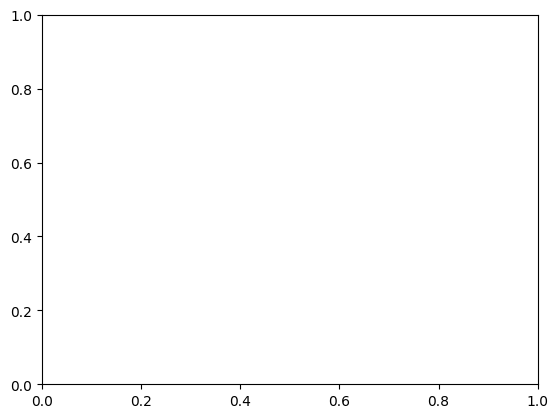

In [19]:
df_tr= resc[~resc['교통사고구분명'].isnull()][['교통사고구분명', '중증외상명']]
df_tr['중증외상_여부']= df_tr['중증외상명'].isnull().astype(int)
df_tr.groupby('교통사고구분명')['중증외상_여부'].mean()

result= df_tr.groupby('교통사고구분명')['중증외상_여부'].agg(전체건수='size', 중증외상건수='sum')

result


result['중증외상비율']= result['중증외상건수']/ result['전체건수'] 
result['중증외상비율'].sort_values(ascending= False)   

plt.ylim()


In [20]:
resc['심정지명'].value_counts()

심정지명
Y    83512
Name: count, dtype: int64

In [36]:
import pandas as pd

print(resc[['신고일자', '신고시각', '신고연도', '신고월', '신고일', '신고시간', '신고분', '신고요일']].head(10))

# 신고일자 + 신고시각 결합
datetime_str = (
    resc['신고일자'].astype(str)
    + resc['신고시각'].astype(str).str.zfill(6)
)

# 문자열을 datetime 타입으로 변환
resc['신고일시'] = pd.to_datetime(
    datetime_str,
    format='%Y%m%d%H%M%S',
    errors='coerce'
)

print(resc[['신고일자', '신고시각', '신고일시']].head(10))

       신고일자   신고시각  신고연도  신고월  신고일  신고시간  신고분 신고요일
0  20230109  90100  2023    1    9     9    1  월요일
1  20230109  90100  2023    1    9     9    1  월요일
2  20230109  90100  2023    1    9     9    1  월요일
3  20230109  90100  2023    1    9     9    1  월요일
4  20230109  90100  2023    1    9     9    1  월요일
5  20230109  90100  2023    1    9     9    1  월요일
6  20230123  70800  2023    1   23     7    8  월요일
7  20230109  90100  2023    1    9     9    1  월요일
8  20230204  83300  2023    2    4     8   33  토요일
9  20230204  83300  2023    2    4     8   33  토요일
       신고일자   신고시각                신고일시
0  20230109  90100 2023-01-09 09:01:00
1  20230109  90100 2023-01-09 09:01:00
2  20230109  90100 2023-01-09 09:01:00
3  20230109  90100 2023-01-09 09:01:00
4  20230109  90100 2023-01-09 09:01:00
5  20230109  90100 2023-01-09 09:01:00
6  20230123  70800 2023-01-23 07:08:00
7  20230109  90100 2023-01-09 09:01:00
8  20230204  83300 2023-02-04 08:33:00
9  20230204  83300 2023-02-04 08:33:00


In [37]:
resc.columns

Index(['구급보고서번호', '등록완료구분명', '환자발생유형명', '환자증상구분명', '중증외상명', '심정지명',
       '심혈관뇌혈관구분명', '교통사고구분명', '기타교통사고명', '동물기타분류명', '기타발생유형명', '소방서명', '센터명',
       '구급활동구분명', '헬기펌뷸런스유무명', '신고일자', '신고시각', '신고연도', '계절명', '분기번호', '신고월',
       '신고일', '신고시간', '신고분', '신고요일', '출동일자', '출동시각&nbsp;', '출동연도', '출동월',
       '출동일', '출동시간', '출동분', '현장도착일자', '현장도착시각', '현장도착연도', '현장도착월', '현장도착일',
       '현장도착시간', '현장도착분', '환자접촉일자', '환자접촉시각', '환자접촉연도', '환자접촉월', '환자접촉일',
       '환자접촉시간', '환자접촉분', '현장거리', '현장출발일자', '현장출발시각', '현장출발연도', '현장출발월',
       '현장출발일', '현장출발시간', '현장출발분', '복귀일자', '복귀시각', '복귀연도', '복귀월', '복귀일',
       '복귀시간', '복귀분', '종결구분명', '성별명', '환자시도명', '시도명', '시군구명', '도시농촌구분명',
       '환자직업명', '2현장거리', '3현장거리', '이송분류명', '신고일시'],
      dtype='object')

In [26]:
resc['기타발생유형명'].value_counts()

기타발생유형명
단순주취           55361
기타             30940
임산부             4566
기타(질병외)           12
낙상                 8
운전자                7
열상                 3
중독                 3
동승자                2
미상                 1
전기사고               1
열실신                1
화염                 1
이물질에대의한기도막힘        1
보행자                1
Name: count, dtype: int64

<Axes: xlabel='신고월'>

c:\Users\KDT30\anaconda3\envs\hani\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\KDT30\anaconda3\envs\hani\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\KDT30\anaconda3\envs\hani\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\KDT30\anaconda3\envs\hani\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KDT30\anaconda3\envs\hani\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\K

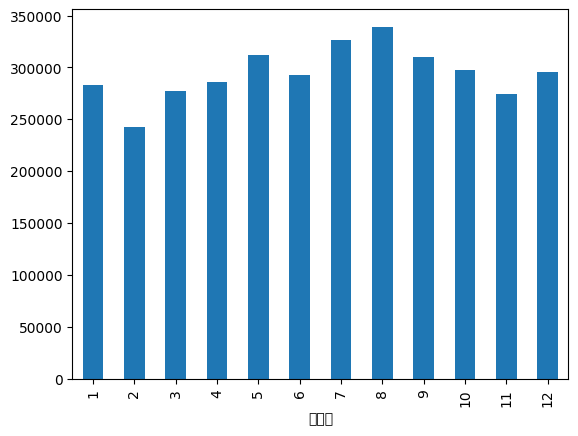

In [38]:
# 월별로--> group by
# (기타발생유형명) 단순 주취, 개수

df=resc[['신고월', '기타발생유형명']]
df= df[df['기타발생유형명']== '단순주취']
df

resc.groupby('신고월').size().plot.bar()



In [ ]:
resc.groupby('계절명')['환자증상구분명'].value_counts()

0          겨울
1          겨울
2          겨울
3          겨울
4          겨울
           ..
3536890    겨울
3536891    겨울
3536892    겨울
3536893    겨울
3536894    겨울
Name: 계절명, Length: 3536895, dtype: object

In [ ]:
def func(df):
    return df.value_counts()[:5]


resc.groupby('계절명')['환자증상구분명'].apply(func)

In [ ]:
type(resc.describe())